In [28]:
import os
import sys 
sys.path.append(os.path.join('..'))


import numpy as np
import torch
import torch.nn.functional as F

from ops.torch_warping import warp_img_torch_3D
from ops.torch_algebra import random_affine_matrix

import nibabel as nib

from pytorch3d.ops import sample_points_from_meshes, cubify
from pytorch3d.transforms import axis_angle_to_matrix, matrix_to_axis_angle

import pyvista as pv
pv.start_xvfb(wait=0)
pv.set_jupyter_backend('html')

import trimesh

import pickle

from GHD.GHD_cardiac import GHD_Cardiac
from GHD import GHD_config

from data_process.dataset_real_scaling import *
import data.data_utils as dut
from torch_scatter import scatter
from einops import rearrange
from ops.medical_related import *

In [29]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# just load the canonical model

root_path = os.path.dirname(os.path.realpath('.'))

base_shape_path = 'canonical_shapes/Standard_LV_2000.obj'
base_shape_path = os.path.join(root_path, base_shape_path)
bi_ventricle_path = 'canonical_shapes/Standard_BiV.obj'
bi_ventricle_path = os.path.join(root_path, bi_ventricle_path)

# base_shape_path = 'metadata/Standard_LV.obj'
# bi_ventricle_path = 'metadata/Standard_BiV.obj'

cfg = GHD_config(base_shape_path=base_shape_path,
            num_basis=6**2, mix_laplacian_tradeoff={'cotlap':1.0, 'dislap':0.1, 'stdlap':0.1},
            device=device,
            if_nomalize=True, if_return_scipy=True, 
            bi_ventricle_path=bi_ventricle_path)

paraheart = GHD_Cardiac(cfg) # 

GHD config:
base_shape_path /home/fanwen/GHDHeart/canonical_shapes/Standard_LV_2000.obj
num_basis 36
device cuda:0
mix_laplacian_tradeoff {'cotlap': 1.0, 'dislap': 0.1, 'stdlap': 0.1}
if_lap_nomalize True
eign_path None
if_nomalize True
if_return_scipy True
bi_ventricle_path /home/fanwen/GHDHeart/canonical_shapes/Standard_BiV.obj


In [30]:
# follow the manner of MMWHS dense CT.
# flags: 
center_aligned = True
rescalar = 1/100

MnMs2_dir = '/media/ssd/fanwen/MultiView/MnM2/dataset'
casesnums = os.listdir(MnMs2_dir)

casesnum = '103'
timing = 'ES'


LA_img_niifile = '{}_LA_{}.nii.gz'.format(casesnum, timing)
SA_img_niifile = '{}_SA_{}.nii.gz'.format(casesnum, timing)

LA_label_niifile = '{}_LA_{}_gt.nii.gz'.format(casesnum, timing)
SA_label_niifile = '{}_SA_{}_gt.nii.gz'.format(casesnum, timing)

LA_img = dut.load_nib_image(os.path.join(MnMs2_dir, casesnum, LA_img_niifile), omit_tranlation = False)
SA_img = dut.load_nib_image(os.path.join(MnMs2_dir, casesnum, SA_img_niifile), omit_tranlation = False)
LA_label = dut.load_nib_image(os.path.join(MnMs2_dir, casesnum, LA_label_niifile), omit_tranlation = False)
SA_label = dut.load_nib_image(os.path.join(MnMs2_dir, casesnum, SA_label_niifile), omit_tranlation = False)
# norm the two into the same space and show.

LA_affine_norm = dut.affine_np2torch_new(affine_np = LA_img['affine'],
                                    img_size_np = LA_img['img'].shape,
                                    center_aligned=False)


SA_affine_norm = dut.affine_np2torch_new(affine_np = SA_img['affine'],
                                    img_size_np = SA_img['img'].shape,
                                    center_aligned=False)

tensor([[127.5000,   0.0000,   0.0000, 127.5000],
        [  0.0000, 127.5000,   0.0000, 127.5000],
        [  0.0000,   0.0000,   0.5000,   0.5000],
        [  0.0000,   0.0000,   0.0000,   1.0000]])
tensor([[127.5000,   0.0000,   0.0000, 127.5000],
        [  0.0000, 127.5000,   0.0000, 127.5000],
        [  0.0000,   0.0000,   5.5000,   5.5000],
        [  0.0000,   0.0000,   0.0000,   1.0000]])


In [31]:
sax_tem = torch.Tensor(SA_label['img']).permute(2,1,0).unsqueeze(0).unsqueeze(0)
sax_tem = sax_tem.to(SA_affine_norm.device)
lax_tem = torch.Tensor(LA_label['img']).permute(2,1,0).unsqueeze(0).unsqueeze(0)
lax_tem = lax_tem.to(LA_affine_norm.device)

coord_map_sax = dut.get_coord_map_3d_normalized_new(sax_tem.shape[-3:], 
                                               SA_affine_norm.unsqueeze(0))
coord_map_sax_np = coord_map_sax[0].numpy()

coord_map_lax = dut.get_coord_map_3d_normalized_new(lax_tem.shape[-3:], 
                                               LA_affine_norm.unsqueeze(0))
coord_map_lax_np = coord_map_lax[0].numpy()

In [32]:
Z, Y, X = sax_tem.shape[-3:]

Z_rv_sax, Y_rv_sax, X_rv_sax = torch.where(sax_tem[0,0]==3)
Z_lv_sax, Y_lv_sax, X_lv_sax = torch.where(sax_tem[0,0]==2)
Z_cav_sax, Y_cav_sax, X_cav_sax = torch.where(sax_tem[0,0]==1)
Z_bg_sax, Y_bg_sax, X_bg_sax = torch.where(sax_tem[0,0]==0)

Pt_rv_sax = coord_map_sax[0, Z_rv_sax, Y_rv_sax, X_rv_sax]
Pt_lv_sax = coord_map_sax[0, Z_lv_sax, Y_lv_sax, X_lv_sax]
Pt_cav_sax = coord_map_sax[0, Z_cav_sax, Y_cav_sax, X_cav_sax]
Pt_bg_sax = coord_map_sax[0, Z_bg_sax, Y_bg_sax, X_bg_sax]


Z, Y, X = lax_tem.shape[-3:]
Z_rv_lax, Y_rv_lax, X_rv_lax = torch.where(lax_tem[0,0]==3)
Z_lv_lax, Y_lv_lax, X_lv_lax = torch.where(lax_tem[0,0]==2)
Z_cav_lax, Y_cav_lax, X_cav_lax = torch.where(lax_tem[0,0]==1)
Z_bg_lax, Y_bg_lax, X_bg_lax = torch.where(lax_tem[0,0]==0)

Pt_rv_lax = coord_map_lax[0, Z_rv_lax, Y_rv_lax, X_rv_lax]
Pt_lv_lax = coord_map_lax[0, Z_lv_lax, Y_lv_lax, X_lv_lax]
Pt_cav_lax = coord_map_lax[0, Z_cav_lax, Y_cav_lax, X_cav_lax]
Pt_bg_lax = coord_map_lax[0, Z_bg_lax, Y_bg_lax, X_bg_lax]

Pt_lv = torch.cat([Pt_lv_sax, Pt_lv_lax], dim=0)
Pt_rv = torch.cat([Pt_rv_sax, Pt_rv_lax], dim=0)
Pt_cav = torch.cat([Pt_cav_sax, Pt_cav_lax], dim=0)
Pt_bg = torch.cat([Pt_bg_sax, Pt_bg_lax], dim=0)

# Pt_lv = Pt_lv_sax
# Pt_rv = Pt_rv_sax
# Pt_cav = Pt_cav_sax
# Pt_bg = Pt_bg_sax

geom_dict = get_4chamberview_frame_rv(Pt_cav,
                                      Pt_lv,
                                      Pt_rv)

# rotate the frames to the 4chamber view first? 
inital_affine = geom_dict['target_affine']
print('inital affine: ', inital_affine)

inital affine:  tensor([[-0.0747, -0.9287, -0.3633,  0.6079],
        [ 0.4670, -0.3545,  0.8101, -0.1300],
        [-0.8811, -0.1092,  0.4602,  0.7197],
        [ 0.0000,  0.0000,  0.0000,  1.0000]])


In [33]:
Pt_lv_cano = Pt_lv @ geom_dict['target_affine'].inverse()[:3,:3].T + geom_dict['target_affine'].inverse()[:3,3]
Pt_rv_cano = Pt_rv @ geom_dict['target_affine'].inverse()[:3,:3].T + geom_dict['target_affine'].inverse()[:3,3]
Pt_cav_cano = Pt_cav @ geom_dict['target_affine'].inverse()[:3,:3].T + geom_dict['target_affine'].inverse()[:3,3]
Pt_bg_cano = Pt_bg @ geom_dict['target_affine'].inverse()[:3,:3].T + geom_dict['target_affine'].inverse()[:3,3]

In [34]:
points_bi_cano = torch.cat([Pt_lv_cano, Pt_rv_cano], dim=0)
points_outoflv_cano = torch.cat([Pt_lv_cano, Pt_cav_cano, Pt_bg_cano], dim=0)
points_lv_cano = Pt_lv_cano

bbox_lv_cano = torch.stack([Pt_lv_cano.min(dim=0)[0]-0.05, Pt_lv_cano.max(dim=0)[0]+0.05], dim=-1)
points_outoflv_in_bbox_cano = points_outoflv_cano[(points_outoflv_cano[:,0]>bbox_lv_cano[0,0]) & 
                                        (points_outoflv_cano[:,0]<bbox_lv_cano[0,1]) & 
                                        (points_outoflv_cano[:,1]>bbox_lv_cano[1,0]) & 
                                        (points_outoflv_cano[:,1]<bbox_lv_cano[1,1]) & 
                                        (points_outoflv_cano[:,2]>bbox_lv_cano[2,0]) & 
                                        (points_outoflv_cano[:,2]<bbox_lv_cano[2,1])]

In [35]:
sample_num = Pt_lv_cano.shape[0]

# mesh_gt_bi_sample = points_bi.detach().cpu().numpy()[np.random.choice(points_bi.shape[0], sample_num, replace=False)]
# paraheart.global_registration_biv(mesh_gt_bi_sample)

sample_lv_cano = Pt_lv_cano[np.random.choice(Pt_lv_cano.shape[0], sample_num, replace=False)]
paraheart.global_registration_lv(sample_lv_cano.detach().cpu().numpy())

{'rot': array([[ 0.99933991,  0.03159514, -0.01793017],
        [-0.02650295,  0.97163529,  0.2349946 ],
        [ 0.02484628, -0.23436428,  0.97183129]]),
 'scale': 1.248138549329314,
 't': array([ 0.00580211, -0.01650392,  0.03423973])}

In [36]:
pl = pv.Plotter(notebook=True)


pl.add_points(Pt_lv_cano.detach().cpu().numpy(), 
             render_points_as_spheres=True, point_size=2, color='blue', opacity=1)
pl.add_points(Pt_rv_cano.detach().cpu().numpy(),
            render_points_as_spheres=True, point_size=2, color='yellow', opacity=1)
pl.add_points(Pt_cav_cano.detach().cpu().numpy(),
               render_points_as_spheres=True, point_size=2, color='red', opacity=1)

   
#out_ghd_mesh = paraheart.rendering()
#trimesh_current_lv = trimesh.Trimesh(out_ghd_mesh.verts_packed().detach().cpu().numpy(), out_ghd_mesh.faces_packed().detach().cpu().numpy())
#pl.add_mesh(trimesh_current_lv, color='lightblue', opacity=0.9, show_edges=True, show_vertices=False)


pl.add_mesh(pv.Box(bounds=[-1, 1, -1, 1, -1, 1]).outline(), color='black')

pl.show()

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

In [10]:
# sample_outoflv = points_outoflv_in_bbox[np.random.choice(points_outoflv_in_bbox.shape[0], sample_num*5, replace=False)]
points_lv_cano = points_lv_cano.to(device)
points_outoflv_in_bbox_cano = points_outoflv_in_bbox_cano.to(device)
convergence, Loss_dict_list = paraheart.morphing2lvtarget(points_lv_cano, 
                                                           points_outoflv_in_bbox_cano, 
                                                           loss_dict = {'Loss_occupancy':1, 'Loss_Laplacian':0.001, 'Loss_thickness': 0.001},
                                                            lr_start=1e-3, 
                                                            num_iter=2000, 
                                                            if_reset=True, 
                                                            if_fit_R=False, 
                                                            if_fit_s=True, 
                                                            if_fit_T=True, 
                                                            record_convergence=True)

Total Loss 0.1973: 100%|██████████| 2000/2000 [01:23<00:00, 23.93it/s]

fittings done, the final loss is 0.197342


In [37]:
pl = pv.Plotter(notebook=True)

img_la = LA_img['img']
img_sa = SA_img['img']

img_sa_zyx = np.transpose(img_sa, (2, 1, 0))  # ZYX to XYZ
img_la_zyx = np.transpose(img_la, (2, 1, 0))  # ZYX to XYZ

vmin = np.percentile(img_sa_zyx, 5)
vmax = np.percentile(img_sa_zyx, 95)

coord_map_sax = dut.get_coord_map_3d_normalized_new(img_sa_zyx.shape, 
                                                    geom_dict['target_affine'].inverse() @ SA_affine_norm.unsqueeze(0))
coord_map_sax_np = coord_map_sax[0].numpy()
for i in range(2,img_sa_zyx.shape[0]-2,1):
    x, y, z = coord_map_sax_np[i,..., 0], coord_map_sax_np[i,..., 1], coord_map_sax_np[i,..., 2]
    grid = pv.StructuredGrid(x, y, z)
    scalars = img_sa_zyx[i].T.flatten()
        # raw_img = img_zyx.astype(np.float32).T.flatten()
    pl.add_mesh(grid, scalars = scalars, cmap = 'gray', clim=(vmin, vmax),
                show_scalar_bar = False, opacity = 0.3)

coord_map_lax = dut.get_coord_map_3d_normalized_new(img_la_zyx.shape, 
                                                    geom_dict['target_affine'].inverse() @ LA_affine_norm.unsqueeze(0))
coord_map_lax_np = coord_map_lax[0].numpy()
x, y, z = coord_map_lax_np[0,..., 0], coord_map_lax_np[0,..., 1], coord_map_lax_np[0,..., 2]
grid = pv.StructuredGrid(x, y, z)
scalars = img_la_zyx[0].T.flatten()
pl.add_mesh(grid, scalars = scalars, cmap = 'gray', clim=(vmin, vmax),
            show_scalar_bar = False, opacity = 0.3)

pl.add_points(points_lv_cano.detach().cpu().numpy(),
              render_points_as_spheres=True, point_size=2, color='lightgreen', opacity=0.5)
   
out_ghd_mesh = paraheart.rendering()
trimesh_current_lv = trimesh.Trimesh(out_ghd_mesh.verts_packed().detach().cpu().numpy(), out_ghd_mesh.faces_packed().detach().cpu().numpy())
pl.add_mesh(trimesh_current_lv, color='lightblue', opacity=0.8, show_edges=True, show_vertices=False)

pl.add_mesh(pv.Box(bounds=[-1, 1, -1, 1, -1, 1]).outline(), color='black')

pl.show()

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

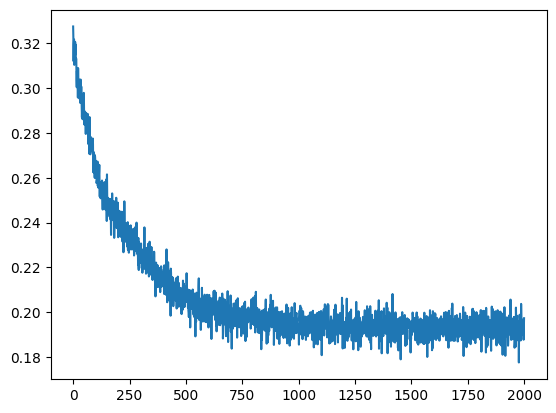

In [12]:
import matplotlib.pyplot as plt
Loss_occupancy = [loss['Loss_occupancy'] for loss in Loss_dict_list]
Loss_occupancy = np.array(Loss_occupancy)
plt.plot(Loss_occupancy)

In [13]:
# try transverse the local deformed heart to canonical space
print('R:', paraheart.R)
print('T:', paraheart.T)
rotation = paraheart.R.detach().cpu()
translation = paraheart.T.detach().cpu()
# transform the R and T to affine matrix
from pytorch3d.transforms import axis_angle_to_matrix
R = axis_angle_to_matrix(rotation).view(3,3)
T = translation.view(3,1)

R: Parameter containing:
tensor([[-0.3624,  0.0069,  0.0164]], device='cuda:0', requires_grad=True)
T: Parameter containing:
tensor([[ 0.0021, -0.0024,  0.0310]], device='cuda:0', requires_grad=True)


In [14]:
affine_new = torch.eye(4)
affine_new[:3,:3] = R
affine_new[:3,3] = T.squeeze().cpu() 
affine_new[3, 3] = 1.0

In [15]:
# final_affine: for the slices, do the target.inverse()
# for the fitted cano mesh, do the affine_new
# slices -> cano:  affine_new.inverse @ target.inverse()
# final_affine = (affine_new.inverse() @ target.inverse()).inverse()
# final_affine = target @ affine_new
final_affine = geom_dict['target_affine'] @ affine_new
final_affine.to(device)

tensor([[-0.1702, -0.8038, -0.5700,  0.6041],
        [ 0.5688, -0.5525,  0.6093, -0.1003],
        [-0.8047, -0.2205,  0.5513,  0.7475],
        [ 0.0000,  0.0000,  0.0000,  1.0000]], device='cuda:0')

In [16]:
# transform the slices back 
paraheart.R = torch.Tensor([0, 0, 0]).view(1,3).to(paraheart.device)
paraheart.T = torch.Tensor([0, 0, 0]).view(1,3).to(paraheart.device)

In [17]:
points_lv_new = Pt_lv @ final_affine.inverse()[:3,:3].T + final_affine.inverse()[:3,3]

In [18]:
pl = pv.Plotter(notebook=True)

img_la = LA_img['img']
img_sa = SA_img['img']

img_sa_zyx = np.transpose(img_sa, (2, 1, 0))  # ZYX to XYZ
img_la_zyx = np.transpose(img_la, (2, 1, 0))  # ZYX to XYZ

vmin = np.percentile(img_sa_zyx, 5)
vmax = np.percentile(img_sa_zyx, 95)

coord_map_sax = dut.get_coord_map_3d_normalized_new(img_sa_zyx.shape, 
                                                    final_affine.inverse() @ SA_affine_norm.unsqueeze(0))
coord_map_sax_np = coord_map_sax[0].numpy()
for i in range(2,img_sa_zyx.shape[0]-2,1):
    x, y, z = coord_map_sax_np[i,..., 0], coord_map_sax_np[i,..., 1], coord_map_sax_np[i,..., 2]
    grid = pv.StructuredGrid(x, y, z)
    scalars = img_sa_zyx[i].T.flatten()
        # raw_img = img_zyx.astype(np.float32).T.flatten()
    pl.add_mesh(grid, scalars = scalars, cmap = 'gray', clim=(vmin, vmax),
                show_scalar_bar = False, opacity = 0.3)
    
coord_map_lax = dut.get_coord_map_3d_normalized_new(img_la_zyx.shape, 
                                                    final_affine.inverse() @ LA_affine_norm.unsqueeze(0))
coord_map_lax_np = coord_map_lax[0].numpy()
x, y, z = coord_map_lax_np[0,..., 0], coord_map_lax_np[0,..., 1], coord_map_lax_np[0,..., 2]
grid = pv.StructuredGrid(x, y, z)
scalars = img_la_zyx[0].T.flatten()
pl.add_mesh(grid, scalars = scalars, cmap = 'gray', clim=(vmin, vmax),
                show_scalar_bar = False, opacity = 0.3)

pl.add_points(points_lv_new.detach().cpu().numpy(),
              render_points_as_spheres=True, point_size=2, color='lightgreen', opacity=0.5)
   
out_ghd_mesh = paraheart.rendering()
trimesh_current_lv = trimesh.Trimesh(out_ghd_mesh.verts_packed().detach().cpu().numpy(), out_ghd_mesh.faces_packed().detach().cpu().numpy())
pl.add_mesh(trimesh_current_lv, color='lightblue', opacity=0.8, show_edges=True, show_vertices=False)

pl.add_mesh(pv.Box(bounds=[-1, 1, -1, 1, -1, 1]).outline(), color='black')

pl.show()

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…